# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name:**  
**Student ID:**

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors — such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers — affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | — |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **— (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [2]:
# Load the dataset
df = pd.read_csv('data/electrical_grid_stability.csv')
print('Dataset loaded successfully.')


Dataset loaded successfully.


In [3]:
# Explore: shape, dtypes, head, missing values, describe, value_counts
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)

print('\nFirst 5 rows:')
display(df.head())

print('Missing values per column:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

print('\nDescriptive statistics (numeric columns):')
print(df.describe())

print('\nTarget distribution (stabf):')
print(df['stabf'].value_counts())


Shape: (10000, 14)

Data types:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

First 5 rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


Missing values per column:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Total missing values: 0

Descriptive statistics (numeric columns):
               tau1          tau2          tau3          tau4            p1  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       5.250000      5.250001      5.250004      5.249997      3.750000   
std        2.742548      2.742549      2.742549      2.742556      0.752160   
min        0.500793      0.500141      0.500788      0.500473      1.582590   
25%        2.874892      2.875140      2.875522      2.874950      3.218300   
50%        5.250004      5.249981      5.249979      5.249734      3.751025   
75%        7.624690      7.624893      7.624948      7.624838      4.282420   
max        9.999469      9.999837      9.999450      9.999443      5.864418   

                 p2       

---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [4]:
# Feature engineering
# 1) Target encoding: unstable -> 1, stable -> 0
df['is_unstable'] = (df['stabf'] == 'unstable').astype(int)

# 2) Total reaction time
df['total_reaction_time'] = df[['tau1', 'tau2', 'tau3', 'tau4']].sum(axis=1)

# 3) Power imbalance
df['power_imbalance'] = df[['p1', 'p2', 'p3', 'p4']].sum(axis=1)

# 4) Average elasticity
df['avg_elasticity'] = df[['g1', 'g2', 'g3', 'g4']].mean(axis=1)

print('New columns created: is_unstable, total_reaction_time, power_imbalance, avg_elasticity')
print('\nPreview of engineered columns:')
display(df[['stabf', 'is_unstable', 'total_reaction_time', 'power_imbalance', 'avg_elasticity']].head())


New columns created: is_unstable, total_reaction_time, power_imbalance, avg_elasticity

Preview of engineered columns:


,stabf,is_unstable,total_reaction_time,power_imbalance,avg_elasticity
0,unstable,1,24.200725,-2.886580e-15,0.838878
1,stable,0,18.623519,-6.661338e-16,0.654938
2,unstable,1,22.081132,0.000000e+00,0.469757
3,unstable,1,15.213218,-9.992007e-16,0.678763
4,unstable,1,25.544216,4.996004e-15,0.682607


In [5]:
# Print class balance
class_counts = df['stabf'].value_counts()
class_pct = df['stabf'].value_counts(normalize=True) * 100

class_balance = pd.DataFrame({
    'count': class_counts,
    'percentage': class_pct.round(2)
})

print('Class balance (stabf):')
print(class_balance)

print(f"\nUnstable ratio (is_unstable=1): {df['is_unstable'].mean():.2%}")


Class balance (stabf):
          count  percentage
stabf                      
unstable   6380        63.8
stable     3620        36.2

Unstable ratio (is_unstable=1): 63.80%


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids — compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [17]:
# Grouped means by stabf
orig_features = [f'tau{i}' for i in range(1, 5)] + [f'p{i}' for i in range(1, 5)] + [f'g{i}' for i in range(1, 5)]

group_means = df.groupby('stabf')[orig_features].mean().T
print('Mean values of 12 original features grouped by stabf:')
print(group_means)

mean_diff = (group_means['unstable'] - group_means['stable']).abs().sort_values(ascending=False)
print('\nFeatures with largest mean differences (absolute):')
print(mean_diff.head(5))


Mean values of 12 original features grouped by stabf:
stabf    stable  unstable
tau1   4.394799  5.735239
tau2   4.353362  5.758752
tau3   4.385360  5.740601
tau4   4.378495  5.744485
p1     3.740077  3.755630
p2    -1.253549 -1.247987
p3    -1.249626 -1.250212
p4    -1.236902 -1.257431
g1     0.453035  0.565832
g2     0.445872  0.569897
g3     0.440618  0.572879
g4     0.450390  0.567334

Features with largest mean differences (absolute):
tau2    1.405391
tau4    1.365990
tau3    1.355241
tau1    1.340440
g3      0.132261
dtype: float64


In [18]:
# Correlation with stab — identify top 3
corr_with_stab = df[orig_features + ['stab']].corr()['stab'].drop('stab')
top3_corr = corr_with_stab.abs().sort_values(ascending=False).head(3)

print('Correlation of each original feature with stab:')
print(corr_with_stab.sort_values(key=np.abs, ascending=False))

print('\nTop 3 features by absolute correlation with stab:')
for feat in top3_corr.index:
    print(f"{feat}: corr = {corr_with_stab[feat]:.4f}")


Correlation of each original feature with stab:
g3      0.308235
g2      0.293601
tau2    0.290975
g1      0.282774
tau3    0.280700
g4      0.279214
tau4    0.278576
tau1    0.275761
p4     -0.020786
p1      0.010278
p2      0.006255
p3     -0.003321
Name: stab, dtype: float64

Top 3 features by absolute correlation with stab:
g3: corr = 0.3082
g2: corr = 0.2936
tau2: corr = 0.2910


In [19]:
# Unstable grids: tau1 range and mean
unstable_df = df[df['stabf'] == 'unstable']

tau1_min = unstable_df['tau1'].min()
tau1_max = unstable_df['tau1'].max()
tau1_mean = unstable_df['tau1'].mean()

print('Unstable grids only — tau1 statistics:')
print(f"Min tau1:  {tau1_min:.4f}")
print(f"Max tau1:  {tau1_max:.4f}")
print(f"Mean tau1: {tau1_mean:.4f}")


Unstable grids only — tau1 statistics:
Min tau1:  0.5013
Max tau1:  9.9995
Mean tau1: 5.7352


In [20]:
# Compare g1 between stable and unstable
g1_stats = df.groupby('stabf')['g1'].agg(['mean', 'std'])
print('g1 comparison by stability group:')
print(g1_stats)


g1 comparison by stability group:
              mean       std
stabf                       
stable    0.453035  0.265280
unstable  0.565832  0.270867


---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

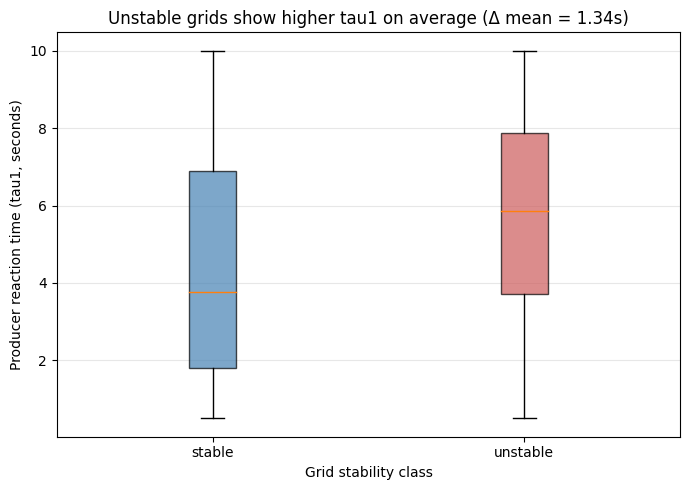

In [28]:
# (a) Boxplot of tau1 by stabf
stable_tau1 = df.loc[df['stabf'] == 'stable', 'tau1']
unstable_tau1 = df.loc[df['stabf'] == 'unstable', 'tau1']

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot([stable_tau1, unstable_tau1], labels=['stable', 'unstable'], patch_artist=True)

colors = ['steelblue', 'indianred']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

mean_diff_tau1 = unstable_tau1.mean() - stable_tau1.mean()
ax.set_xlabel('Grid stability class')
ax.set_ylabel('Producer reaction time (tau1, seconds)')
ax.set_title(f'Unstable grids show higher tau1 on average (Δ mean = {mean_diff_tau1:.2f}s)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


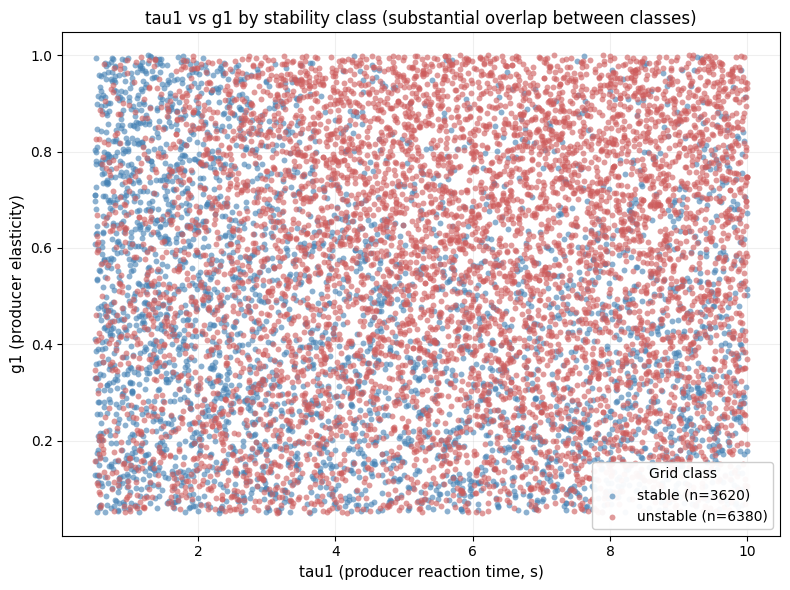

In [45]:
# (b) Scatter plot of tau1 vs g1, colored by stabf
fig, ax = plt.subplots(figsize=(8, 6))

class_colors = {'stable': 'steelblue', 'unstable': 'indianred'}

for cls in ['stable', 'unstable']:
    subset = df[df['stabf'] == cls]
    ax.scatter(
        subset['tau1'], subset['g1'],
        color=class_colors[cls],
        alpha=0.62,
        s=18,
        linewidth=0,
        label=f"{cls} (n={len(subset)})"
    )

# Professional styling: clear labels, subtle grid, clean legend
ax.set_xlabel('tau1 (producer reaction time, s)', fontsize=11)
ax.set_ylabel('g1 (producer elasticity)', fontsize=11)
ax.set_title('tau1 vs g1 by stability class (substantial overlap between classes)', fontsize=12)
ax.grid(True, alpha=0.2)
ax.set_axisbelow(True)

legend = ax.legend(title='Grid class', frameon=True)
legend.get_frame().set_alpha(0.95)

plt.tight_layout()
plt.show()


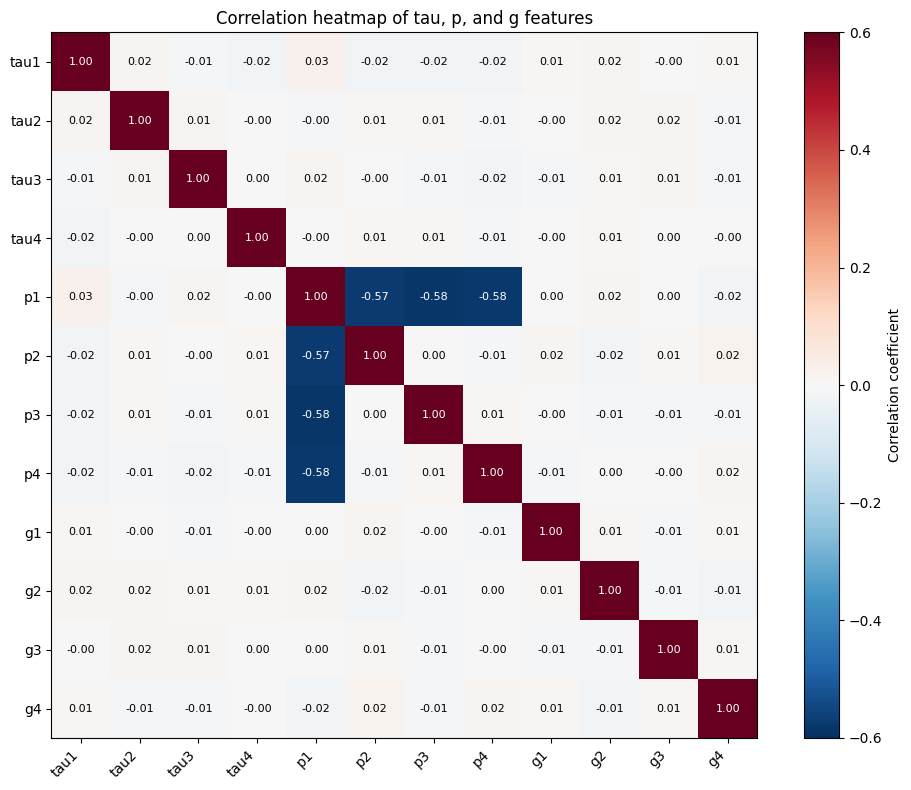

In [46]:
# (c) Correlation heatmap of 12 original features
corr_12 = df[orig_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_12, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(orig_features)))
ax.set_yticks(range(len(orig_features)))
ax.set_xticklabels(orig_features, rotation=45, ha='right')
ax.set_yticklabels(orig_features)
ax.set_title('Correlation heatmap of tau, p, and g features')

# Annotate only clearly strong correlations (including diagonal)
for i in range(len(orig_features)):
    for j in range(len(orig_features)):
        val = corr_12.iloc[i, j]
        if abs(val) >= 0.55:
            text_color = 'white' if abs(val) >= 0.75 else 'black'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=8, color=text_color)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation coefficient')

plt.tight_layout()
plt.show()


---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [37]:
# Z-scores for tau1
tau1_z = stats.zscore(df['tau1'])
outlier_mask = np.abs(tau1_z) > 2
outliers_tau1 = df.loc[outlier_mask, ['tau1', 'stabf']].copy()
outliers_tau1['tau1_zscore'] = tau1_z[outlier_mask]

print(f"Number of samples with |z| > 2 for tau1: {outlier_mask.sum()}")
if outlier_mask.sum() > 0:
    print('\nSample outliers (first 10):')
    display(outliers_tau1.head(10))
else:
    print('No tau1 samples exceed |z| > 2.')


Number of samples with |z| > 2 for tau1: 0
No tau1 samples exceed |z| > 2.


In [38]:
# Two-sample t-test: tau1 stable vs unstable
stable_tau1 = df.loc[df['stabf'] == 'stable', 'tau1']
unstable_tau1 = df.loc[df['stabf'] == 'unstable', 'tau1']

# Welch's t-test (does not assume equal variances)
t_stat, p_val = stats.ttest_ind(stable_tau1, unstable_tau1, equal_var=False)

print('Two-sample t-test for tau1 (stable vs unstable):')
print(f't-statistic = {t_stat:.4f}')
print(f'p-value     = {p_val:.4e}')


Two-sample t-test for tau1 (stable vs unstable):
t-statistic = -23.3033
p-value     = 1.3928e-115


### Interpretation

**H0:** The mean `tau1` is the same for stable and unstable grids (\(\mu_{stable} = \mu_{unstable}\)).  
**H1:** The mean `tau1` differs between stable and unstable grids (\(\mu_{stable} \neq \mu_{unstable}\)).  
**Result:** We reject H0 at \(\alpha = 0.05\), because the p-value is extremely small (\(p \ll 0.05\)). So, `tau1` differs significantly between the two groups.  

**Most predictive feature:** Based on the absolute correlation analysis with continuous `stab`, **`g3`** appears most predictive among original features (\(|r| \approx 0.308\), highest in Task 3/5). This is numerically stronger than other candidates in the top 3 (`g2`, `tau2`), so `g3` is the best single-feature choice from the evidence.

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` — **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [41]:
# Define X and y, split, scale
orig_features = [f'tau{i}' for i in range(1, 5)] + [f'p{i}' for i in range(1, 5)] + [f'g{i}' for i in range(1, 5)]

X = df[orig_features]
y = df['is_unstable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on training
X_test_scaled = scaler.transform(X_test)         # transform test with train stats

print('Data split and scaling completed.')
print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')
print('Scaling check: fit on training only (no leakage).')


Data split and scaling completed.
X_train shape: (8000, 12), X_test shape: (2000, 12)
Scaling check: fit on training only (no leakage).


In [42]:
# Train, predict, evaluate
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec_unstable = precision_score(y_test, y_pred, pos_label=1)
rec_unstable = recall_score(y_test, y_pred, pos_label=1)
f1_unstable = f1_score(y_test, y_pred, pos_label=1)
cm = confusion_matrix(y_test, y_pred)

print('Logistic Regression Results (positive class = unstable):')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec_unstable:.4f}')
print(f'Recall   : {rec_unstable:.4f}')
print(f'F1-score : {f1_unstable:.4f}')

print('\nConfusion Matrix [rows=true, cols=pred]:')
print(cm)


Logistic Regression Results (positive class = unstable):
Accuracy : 0.8200
Precision: 0.8408
Recall   : 0.8856
F1-score : 0.8626

Confusion Matrix [rows=true, cols=pred]:
[[ 510  214]
 [ 146 1130]]


In [43]:
# Optional extension: Threshold tuning for safety-oriented decision making
# Why: In this problem, missing an unstable grid (False Stable / FN) is more dangerous.
# So we tune the threshold to increase recall for the unstable class.

y_proba = clf.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (unstable)

threshold_grid = np.arange(0.20, 0.81, 0.05)
rows = []

for t in threshold_grid:
    y_pred_t = (y_proba >= t).astype(int)
    prec_t = precision_score(y_test, y_pred_t, pos_label=1)
    rec_t = recall_score(y_test, y_pred_t, pos_label=1)
    f1_t = f1_score(y_test, y_pred_t, pos_label=1)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    rows.append([t, prec_t, rec_t, f1_t, fp, fn, tp, tn])

threshold_results = pd.DataFrame(
    rows,
    columns=['threshold', 'precision', 'recall', 'f1', 'FP', 'FN', 'TP', 'TN']
)

print('Threshold tuning table (unstable class):')
print(threshold_results.round(4).to_string(index=False))

# Decision rule:
# 1) Require high recall (>= 0.92) due to safety risk of FN
# 2) Among those, choose the threshold with highest F1 (best balance)
recall_target = 0.92
candidates = threshold_results[threshold_results['recall'] >= recall_target]

if len(candidates) > 0:
    best_row = candidates.sort_values('f1', ascending=False).iloc[0]
else:
    # fallback: if no threshold reaches target recall, pick max recall
    best_row = threshold_results.sort_values('recall', ascending=False).iloc[0]

best_threshold = float(best_row['threshold'])
print('\nSelected threshold (safety-oriented):', best_threshold)
print(f"Reason: recall >= {recall_target:.2f} target and best F1 among candidates.")

# Compare default threshold (0.50) vs tuned threshold
for t_label, t_val in [('Default', 0.50), ('Tuned', best_threshold)]:
    y_pred_cmp = (y_proba >= t_val).astype(int)
    prec_cmp = precision_score(y_test, y_pred_cmp, pos_label=1)
    rec_cmp = recall_score(y_test, y_pred_cmp, pos_label=1)
    f1_cmp = f1_score(y_test, y_pred_cmp, pos_label=1)
    cm_cmp = confusion_matrix(y_test, y_pred_cmp)

    print(f"\n{t_label} threshold = {t_val:.2f}")
    print(f"Precision: {prec_cmp:.4f} | Recall: {rec_cmp:.4f} | F1: {f1_cmp:.4f}")
    print('Confusion matrix [rows=true, cols=pred]:')
    print(cm_cmp)

Threshold tuning table (unstable class):
 threshold  precision  recall     f1  FP  FN   TP  TN
      0.20     0.7341  0.9890 0.8427 457  14 1262 267
      0.25     0.7520  0.9741 0.8488 410  33 1243 314
      0.30     0.7759  0.9632 0.8594 355  47 1229 369
      0.35     0.7912  0.9412 0.8597 317  75 1201 407
      0.40     0.8041  0.9295 0.8622 289  90 1186 435
      0.45     0.8272  0.9114 0.8673 243 113 1163 481
      0.50     0.8408  0.8856 0.8626 214 146 1130 510
      0.55     0.8573  0.8613 0.8593 183 177 1099 541
      0.60     0.8718  0.8260 0.8483 155 222 1054 569
      0.65     0.8855  0.7939 0.8372 131 263 1013 593
      0.70     0.8980  0.7453 0.8146 108 325  951 616
      0.75     0.9066  0.6920 0.7849  91 393  883 633
      0.80     0.9221  0.6309 0.7492  68 471  805 656

Selected threshold (safety-oriented): 0.39999999999999997
Reason: recall >= 0.92 target and best F1 among candidates.

Default threshold = 0.50
Precision: 0.8408 | Recall: 0.8856 | F1: 0.8626
Confusion 

---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

In power grid management, **False Stable** errors are more dangerous because they miss truly unstable configurations and can lead to blackouts, equipment damage, or cascading failures in real operations. A **False Unstable** prediction is costly (unnecessary intervention), but it is usually safer than missing a real instability event. Therefore, we should prioritize **recall for the unstable class** (catch as many truly unstable cases as possible), while keeping precision at an acceptable level.

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

No, correlation does **not** prove causation. A strong correlation between `tau1` and instability means they move together statistically, but it does not prove that slow producer reaction time is the direct cause. A confounding variable could influence both variables at once; for example, an unobserved system stress condition (such as high-demand operating regime or network loading pattern) could simultaneously increase reaction delays and increase instability risk, creating correlation even without direct causality.

---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr